In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/monthly-airline-passengers.csv"

df = pd.read_csv(url, usecols=[1])
data = df.values.astype("float32")

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [3]:
SEQ_LENGTH = 10

X = np.array([data_scaled[i:i+SEQ_LENGTH]
              for i in range(len(data_scaled)-SEQ_LENGTH)])

y = np.array([data_scaled[i+SEQ_LENGTH]
              for i in range(len(data_scaled)-SEQ_LENGTH)])

train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)

X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=16,
    shuffle=True
)

In [5]:
import torch.nn as nn

class BiRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(1, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

In [6]:
class FeedforwardNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(torch.relu(self.fc1(x)))

In [7]:
def train_model(model, epochs=100):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.5f}")

In [8]:
birnn = BiRNN()
train_model(birnn)

ffnn = FeedforwardNN()
train_model(ffnn)

Epoch 20, Loss: 0.00415
Epoch 40, Loss: 0.00158
Epoch 60, Loss: 0.00141
Epoch 80, Loss: 0.00122
Epoch 100, Loss: 0.00206
Epoch 20, Loss: 0.00370
Epoch 40, Loss: 0.00258
Epoch 60, Loss: 0.00121
Epoch 80, Loss: 0.00089
Epoch 100, Loss: 0.00082


In [9]:
birnn.eval()
ffnn.eval()

with torch.no_grad():
    pred_birnn = birnn(X_test).numpy()
    pred_ffnn = ffnn(X_test).numpy()

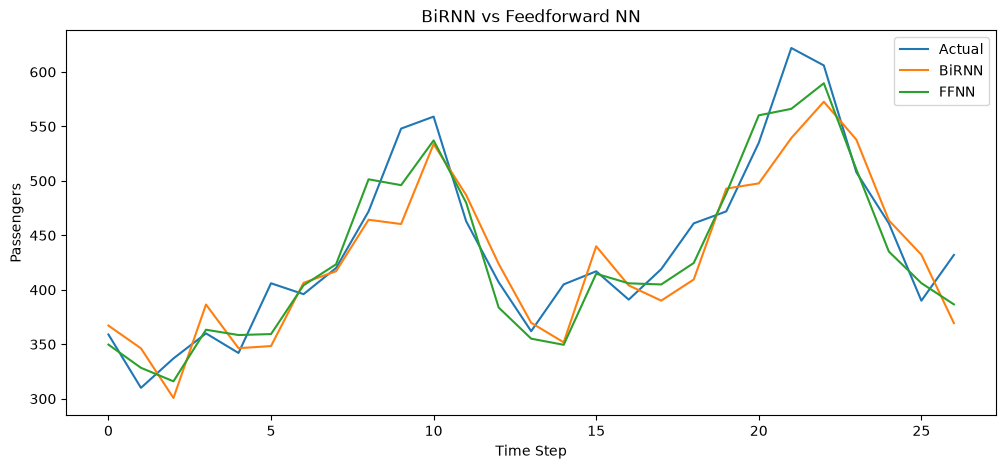

In [10]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

actual = scaler.inverse_transform(y_test.numpy())
p1 = scaler.inverse_transform(pred_birnn)
p2 = scaler.inverse_transform(pred_ffnn)

plt.figure(figsize=(12,5))
plt.plot(actual, label="Actual")
plt.plot(p1, label="BiRNN")
plt.plot(p2, label="FFNN")
plt.legend()
plt.title("BiRNN vs Feedforward NN")
plt.xlabel("Time Step")
plt.ylabel("Passengers")
plt.show()

In [11]:
print("BiRNN MSE:", mean_squared_error(actual, p1))
print("FFNN MSE:", mean_squared_error(actual, p2))

BiRNN MSE: 1464.923583984375
FFNN MSE: 756.930908203125
